In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

load_dotenv()

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")


class BlogState(TypedDict):
    topic: str
    detailed_outline: str
    detailed_blog:str

In [4]:
def blogOutline(state:BlogState)->BlogState:
    topic=state['topic']
    prompt=f"Generate outline for the topic {topic}"
    result=model.invoke(prompt).content
    state["detailed_outline"]=result
    return state

def detailedBlog(state:BlogState)->BlogState:
    topic=state["topic"]
    detailed_outline=state["detailed_outline"]
    prompt=f"Generate a detailed Blog on topic {topic} using the following outline\n {detailed_outline}"
    result=model.invoke(prompt).content
    state["detailed_blog"]=result
    return state

In [10]:
graph=StateGraph(BlogState)
graph.add_node("blogOutline",blogOutline)
graph.add_node("detailedBlog",detailedBlog)
graph.add_edge(START,"blogOutline")
graph.add_edge("blogOutline","detailedBlog")
graph.add_edge("blogOutline",END)
workflow=graph.compile()

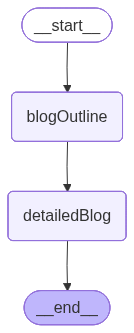

In [11]:
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
result=workflow.invoke({"topic":"Ai s boon or curse"})
print(result['detailed_outline'])
print(result['detailed_blog'])

KeyError: 'detailed_outline'